In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("AB_NYC_2019.csv")
print("intial shape:",df.shape)

intial shape: (48895, 16)


In [3]:
#1.data integrity
#check data types
print(df.dtypes)


id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [7]:
#2.missing data handling
#check miss values
print(df.isnull().sum())

#fill missing values
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

#for name & host_name-> fill with 'unknown'
df['name']=df['name'].fillna('unknown')
df['host_name']=df['host_name'].fillna('unknown')

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [5]:
#fill missing values
df=df.fillna({
    'name':'Unkown',
    'host_name':'Unkown',
    'reviews_per_month':0
})
df=df.infer_objects(copy=False)

In [6]:
#verify
print("after handling missing values:\n",df.isnull().sum())

after handling missing values:
 id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [8]:
#3.duplicate removal
#check dulpivates
print("Duplicate rows:",df.duplicated().sum())
#drop duplicates
df.drop_duplicates(inplace=True)
print("After removing duplicates:",df.shape)


Duplicate rows: 0
After removing duplicates: (48895, 16)


In [10]:
#4.standardization
#convert colum names to lowercase
df.columns=df.columns.str.lower()

#replace spaces
df.columns=df.columns.str.replace(" ","_")
#remove extra spaces in text columns
df['neighbourhood']=df['neighbourhood'].str.lower().str.strip()
df['room_type']=df['room_type'].str.lower().str.strip()


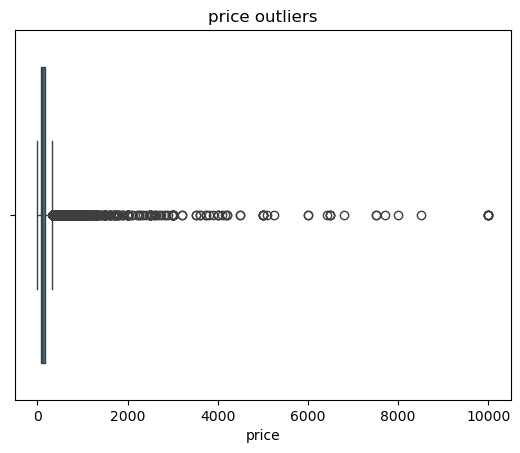

In [11]:
#5.outlier detection &handling
import seaborn as sns
import matplotlib.pyplot as plt

#boxplot for price
plt.figure()
sns.boxplot(x=df['price'])
plt.title('price outliers')
plt.show()

#remove outlines using IQR
q1=df['price'].quantile(0.25)
q3=df['price'].quantile(0.75)




In [12]:
#7.final clean datasset
#save cleaned data
df.to_csv("cleaned_AB_VYC_2019.csv",index=False)

print("data cleaning completed!")
print("final shape:",df.shape)

data cleaning completed!
final shape: (48895, 16)
